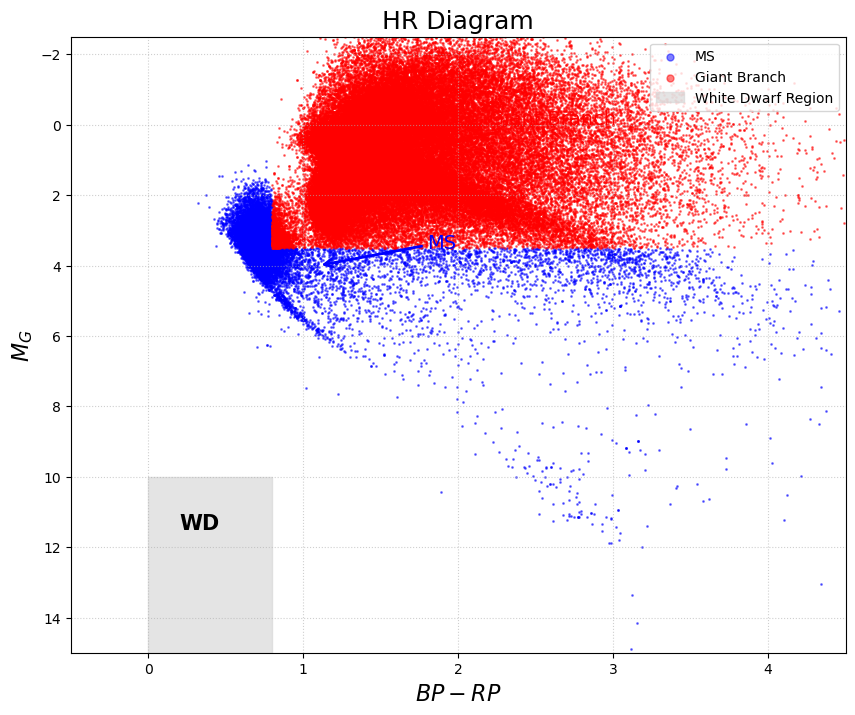

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# Quality Filtering
# We select stars with robust measurements based on the provided criteria
mask = (
    (data['STARFLAG'] == 0) & 
    (data['ASPCAPFLAG'] == 0) & 
    (data['SNR'] > 10) & 
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
clean_data = data[mask]

# Sample 80% of the data
n_samples = int(0.8 * len(clean_data))
indices = np.random.choice(len(clean_data), n_samples, replace=False)
sample = clean_data[indices]

# 4. Calculate Physics Quantities
# X-axis: Color (BP - RP)
bp_rp = sample['GAIAEDR3_PHOT_BP_MEAN_MAG'] - sample['GAIAEDR3_PHOT_RP_MEAN_MAG']

# Y-axis: Absolute Magnitude (M_G) using Distance Modulus
# Formula: M_G = m_G + 5*log10(parallax/1000) + 5
m_g = sample['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = sample['GAIAEDR3_PARALLAX']
M_G = m_g + 5 * np.log10(parallax / 1000) + 5

# 5. Classification
# Giant Branch: M_G < 3.5 and (BP - RP) > 0.8
is_giant = (M_G < 3.5) & (bp_rp > 0.8)
is_ms = ~is_giant

# 6. Plotting
plt.figure(figsize=(10, 8))

# Scatter plots with small markers (s=1) and transparency (alpha) to avoid "blocks"
plt.scatter(bp_rp[is_ms], M_G[is_ms], s=1, c='blue', alpha=0.5, label='MS')
plt.scatter(bp_rp[is_giant], M_G[is_giant], s=1, c='red', alpha=0.5, label='Giant Branch')

# 7. Add White Dwarf (WD) Region
# Box criteria: (BP - RP) <= 0.8 and M_G > 10
wd_box = plt.Rectangle((0, 10), 0.8, 5, color='lightgray', alpha=0.6, label='White Dwarf Region')
plt.gca().add_patch(wd_box)
plt.text(0.2, 11.5, 'WD', fontsize=15, fontweight='bold', color='black')

# 8. Add Arrows and Text Labels
plt.annotate('Giant Branch', xy=(1.5, 1), xytext=(2.2, 0), color='red', fontsize=14,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.annotate('MS', xy=(1.1, 4), xytext=(1.8, 3.5), color='blue', fontsize=14,
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# 9. Final Customization
plt.gca().invert_yaxis()  # Brightest stars (lowest magnitude) at the top
plt.xlabel(r'$BP - RP$', fontsize=16)
plt.ylabel(r'$M_G$', fontsize=16)
plt.title('HR Diagram', fontsize=18)
plt.xlim(-0.5, 4.5)
plt.ylim(15, -2.5) # Inverted limits
plt.legend(loc='upper right', markerscale=5)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()